# **Importing All Libraries For Work**

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from keras.utils import to_categorical

# **Loading Data Sets**

> **Visit this Kaggle DataSet**: [MNIST](https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras/input?select=train.csv.)

> **Download Both Training & Testing DATA**

In [95]:
df: pd.DataFrame = pd.read_csv('mnist_train.csv', on_bad_lines='skip')

In [96]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **Base EDA(Exploratory Data Analysis) & Data Cleaning For Data Set**






In [97]:
df.shape

(42000, 785)

In [98]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [100]:
df.isna().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [101]:
df = df.dropna()

In [102]:
df.isna().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [103]:
df_test.isna().sum()

,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [104]:
df_test = df_test.dropna()

In [105]:
df_test.isna().sum()

,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


# **Data Preprocessing & Normalization**

**Prepares the raw data for the model by splitting features from labels, then scaling the images.**


>
**Train/Test Split**: Separates the data into inputs (X_train, X_test) by dropping the "label" column, and targets (y_train, y_test) by isolating the "label" column. .values converts them into NumPy arrays.

>
**Normalization**: Converts pixel data to float32 and divides by 255.0. This scales pixel values from 0–255 down to a 0.0–1.0 range, which helps the model train faster.

In [106]:
# Creating X and y
X = df.drop('label', axis=1).values
y = df['label'].values

In [107]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
# Normalization
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# **Reshaping Data for Image Processing**

> This step transforms the flat **1D pixel arrays** (784 values) back into 2**D image grids of 28x22** pixels. The **-1** automatically calculates the number of images, while **28, 28** defines their height and width. This **2D structure** is required for **spatial algorithms** like **Convolutional Neural Networks (CNNs)** to recognize **visual patterns**.

In [109]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [110]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

# **Performing One Hot Encoding**

In this step, we transform our target variables (`y_train` and `y_test`) using Keras' `to_categorical` function.
*   **Why we do this:** Our neural network's output layer uses the `softmax` activation function, which outputs a probability distribution across 10 classes. To calculate the categorical crossentropy loss effectively, the true labels must be in the same format.
*   **The transformation:** An integer label like `5` is converted into a vector of length 10: `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`, where the index of the '1' corresponds to the digit class.

In [111]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# **Creating, Training & Evaluation the Perceptron Model**

We construct and train the model as follows:

1. `Flatten(input_shape=(28,28))`: Reshapes the input images from a 2D grid into a 1D vector.
2. `Dense(10, activation='softmax')`: A fully connected layer with 10 output neurons. Since we performed one-hot encoding on our labels earlier (`y_train_cat`), this layer will output probabilities for each of the 10 digit classes.

**Compilation:**
We use `perceptron.compile()` to configure the learning process:
*   **Optimizer (`sgd`):** Stochastic Gradient Descent adjusts the weights to minimize the error.
*   **Loss (`categorical_crossentropy`):** The standard loss function for multi-class classification with one-hot encoded labels.
*   **Metrics (`accuracy`):** We track the percentage of correctly classified images during training.

**Training:**
Finally, we fit the model to our training data using `perceptron.fit()`. We run it for `10` epochs with a `batch_size` of `32`, while passing our test data as `validation_data` to monitor performance on unseen data after each epoch.

In [112]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

In [113]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [91]:
history_perceptron = perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9066 - loss: 0.3350 - val_accuracy: 0.9035 - val_loss: 0.3475
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9079 - loss: 0.3301 - val_accuracy: 0.9054 - val_loss: 0.3430
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9091 - loss: 0.3257 - val_accuracy: 0.9063 - val_loss: 0.3393
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9107 - loss: 0.3217 - val_accuracy: 0.9068 - val_loss: 0.3366
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9111 - loss: 0.3183 - val_accuracy: 0.9070 - val_loss: 0.3340
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9120 - loss: 0.3149 - val_accuracy: 0.9076 - val_loss: 0.3318
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9129 - loss: 0.3120 - val_accuracy: 0.9081 - val_loss: 0.3303
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9134 - loss: 0.3095 - 

In [114]:
accuracy_perceptron = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]
print(f"Perceptron Accuracy: {accuracy_perceptron * 100:.2f}%")

Perceptron Accuracy: 7.40%


# **Creating, Training & Evaluating ANN Model**

Here we define a Multilayer Perceptron (MLP) to improve upon our baseline Perceptron model:

*   **Architecture:**
    *   `Flatten(input_shape=(28,28))`: Prepares the image data.
    *   `Dense(128, activation='relu')`: First hidden layer with 128 neurons. ReLU introduces non-linearity, allowing the network to learn complex features.
    *   `Dense(64, activation='relu')`: Second hidden layer with 64 neurons, further refining the learned features.
    *   `Dense(10, activation='softmax')`: Output layer for 10-class classification.

*   **Compilation:** We use the `adam` optimizer (an adaptive learning rate method) and `categorical_crossentropy` for the loss function.

*   **Training:** The model is trained for `5` epochs with a `batch_size` of `32`, using the test set as `validation_data` to monitor performance after each epoch.

*   **Evaluation:** We use `ann.evaluate()` to calculate the final accuracy on the unseen test data.

In [92]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [93]:
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [116]:
history_ann = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9867 - loss: 0.0416 - val_accuracy: 0.9721 - val_loss: 0.0959
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9893 - loss: 0.0317 - val_accuracy: 0.9690 - val_loss: 0.1180
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9920 - loss: 0.0262 - val_accuracy: 0.9675 - val_loss: 0.1255
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9924 - loss: 0.0240 - val_accuracy: 0.9707 - val_loss: 0.1163
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9949 - loss: 0.0162 - val_accuracy: 0.9726 - val_loss: 0.1134


In [121]:
accuracy_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
print(f"ANN(Artificial Neural Network) Accuracy: \033[1m{accuracy_ann*100:.2f}%\033[0m")

# You can see that \033... like thing i just ask deepseek how to make the
# text bold so model provide me this code, we are in the era where memoizing
# syntax is dead, so in Machine & Deep Learning you cant memoize things like
# in python you can memoize functions after lots of practive but in this domain
# you cant because there are thousands of functions and every function class has
# 10,20 arguments so have to study docs get knowledge from ai, thats the only
# thing which can lead you towards professional ai ml engineer, so make projects
# do much more stuff and practice alot on good projects try to do and right code
# yourself first then you can use ai for syntax as well

ANN(Artificial Neural Network) Accuracy: 97.26%


# **Data Preparation for CNN**
Unlike standard ANNs, CNNs require the input data to maintain its spatial dimensions (Height x Width x Channels). We reshape `X_train` and `X_test` from flattened 784-pixel arrays into `(-1, 28, 28, 1)` tensors. The `1` indicates a single channel because MNIST images are grayscale.

# **CNN Architecture**
We define a Convolutional Neural Network designed to automatically extract spatial features:
*   **Convolutional Base:**
    *   `Conv2D(32, (3,3), relu)`: Learns 32 low-level features (edges, curves).
    *   `MaxPooling2D((2,2))`: Downsamples the image by half to reduce computation.
    *   `Conv2D(64, (3,3), relu)`: Combines low-level features into more complex patterns.
    *   `MaxPooling2D((2,2))`: Further downsampling.
*   **Classifier Head:**
    *   `Flatten()`: Converts the 3D feature maps into a 1D vector.
    *   `Dense(128, relu)`: Fully connected layer for high-level reasoning.
    *   `Dropout(0.5)`: Randomly drops 50% of neurons during training to force the network to learn robust features and prevent overfitting.
    *   `Dense(10, softmax)`: Outputs probability distributions for the 10 digit classes.

# **Compilation and Training**
We compile the model using the `adam` optimizer and `categorical_crossentropy` loss. The model is trained (`cnn.fit`) for `5` epochs with a batch size of 32, using our reshaped data and tracking validation performance.

# **Evaluation**
We evaluate the trained CNN on unseen test data (`X_test_cnn`). The model achieves an impressive **98.90% accuracy**, outperforming the previous standard ANN model.

In [126]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [127]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [128]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [129]:
history_cnn = cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.9136 - loss: 0.2798 - val_accuracy: 0.9773 - val_loss: 0.0713
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9694 - loss: 0.1004 - val_accuracy: 0.9827 - val_loss: 0.0579
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.9778 - loss: 0.0728 - val_accuracy: 0.9871 - val_loss: 0.0403
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9819 - loss: 0.0584 - val_accuracy: 0.9865 - val_loss: 0.0406
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9848 - loss: 0.0490 - val_accuracy: 0.9890 - val_loss: 0.0348


In [130]:
ann_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
print(f"CNN(Convolutional Neural Network) Accuracy: \033[1m{ann_cnn*100:.2f}%\033[0m")

CNN(Convolutional Neural Network) Accuracy: 98.90%


# **Visualizing All Model Accuracy & Loss**

To better understand the performance differences between our Perceptron, ANN, and CNN models, we plot their training histories.

We have defined a reusable helper function, `plot_training()`, which takes the `history` object returned by `model.fit()` and generates two subplots:
1.  **Accuracy Plot:** Shows how the model's prediction accuracy improves over epochs for both Training and Validation sets.
2.  **Loss Plot:** Shows how the error (categorical crossentropy) decreases over epochs.

By comparing these plots side-by-side, we can visually confirm how the deeper architectures (ANN and CNN) outperform the simple linear Perceptron, and observe how techniques like Dropout in the CNN help prevent overfitting.

> Bottom Line: I asks deepseek for the visualization code because i will right all the function by my hand for 1 hour which ai can do in 2,3 seconds

In [135]:
def plot_training(history, title) -> None:
    plt.figure(figsize=(12,4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()

    plt.show()
    return None

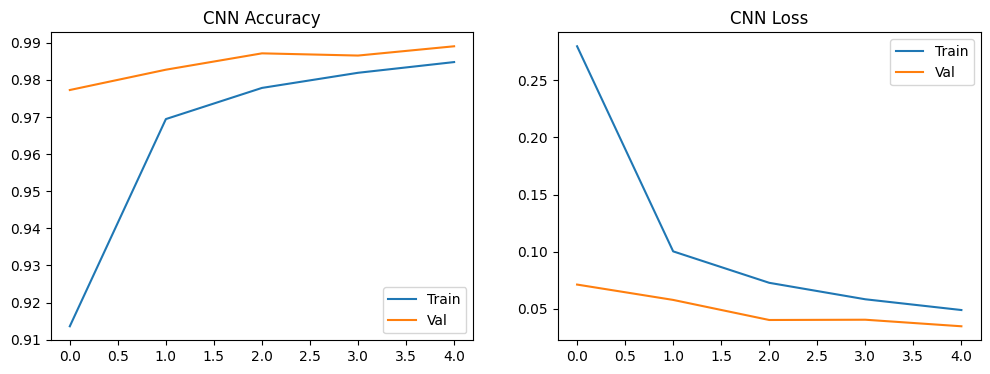

In [136]:
plot_training(history_cnn, "CNN")

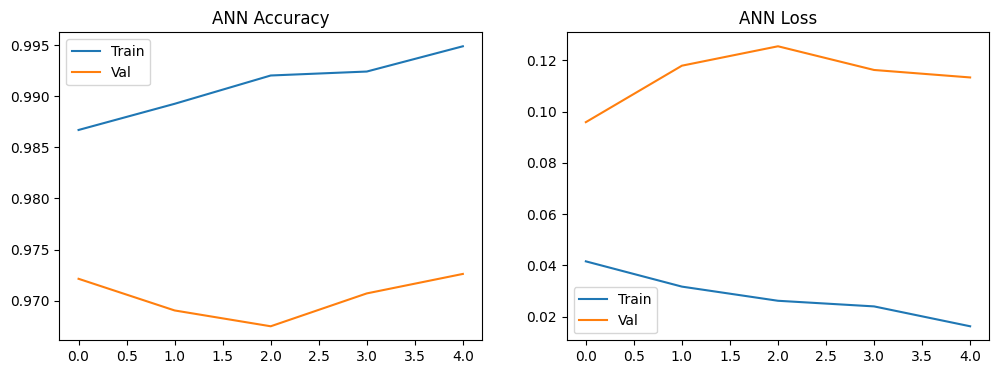

In [137]:
plot_training(history_ann, "ANN")

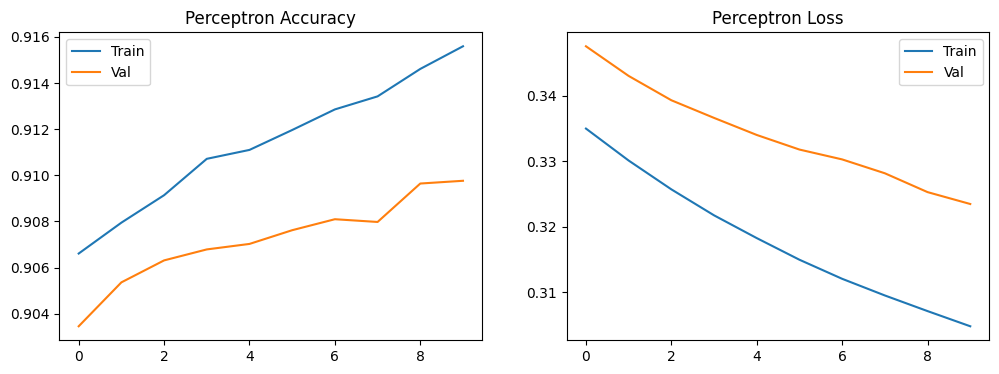

In [138]:
plot_training(history_perceptron, "Perceptron")

In [139]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):
        # Show the original image
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        # Get predictions
        preds = []
        for model, name in zip(models, model_names):
            # If it's the CNN, use the reshaped 4D data. Otherwise use the flat 2D data.
            input_data = X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)
            pred = np.argmax(model.predict(input_data, verbose=0))
            preds.append(pred)

        # Show predictions below the image
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))

    plt.tight_layout()
    plt.show()

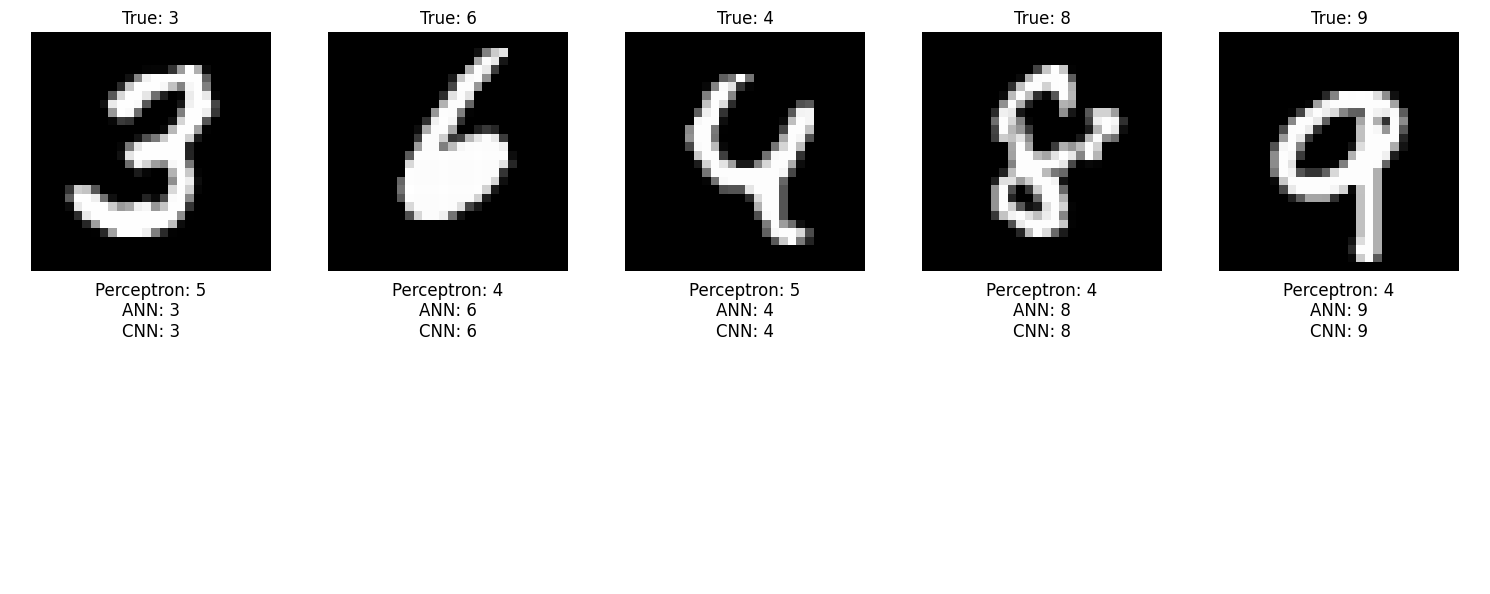

In [140]:
# Call the function
show_side_by_side(
    models=[perceptron, ann, cnn],            # List of your trained model variables
    model_names=["Perceptron", "ANN", "CNN"], # List of names (must match the CNN name for reshaping logic)
    X=X_test_img,                             # The flat test images (for Perceptron and ANN)
    X_cnn=X_test_cnn,                         # The reshaped 4D test images (for CNN)
    y_true=y_test,                            # The true integer labels (0-9)
    n=5                                       # Number of random images to show
)

In [141]:
def plot_confusion_heatmaps(models, model_names, X_flat, X_cnn, y_true):
    plt.figure(figsize=(20, 6)) # Wide figure to fit 3 heatmaps side-by-side

    for i, (model, name) in enumerate(zip(models, model_names)):
        # 1. Prepare the data based on the model type
        if name == "CNN":
            # CNN needs the 4D reshaped data
            predictions = model.predict(X_cnn, verbose=0)
        else:
            # Perceptron and ANN need the flat 2D data
            predictions = model.predict(X_flat, verbose=0)

        # 2. Convert probabilities to actual digit predictions (0-9)
        y_pred = np.argmax(predictions, axis=1)

        # 3. Calculate the Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)

        # 4. Plot the Heatmap
        plt.subplot(1, 3, i+1)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

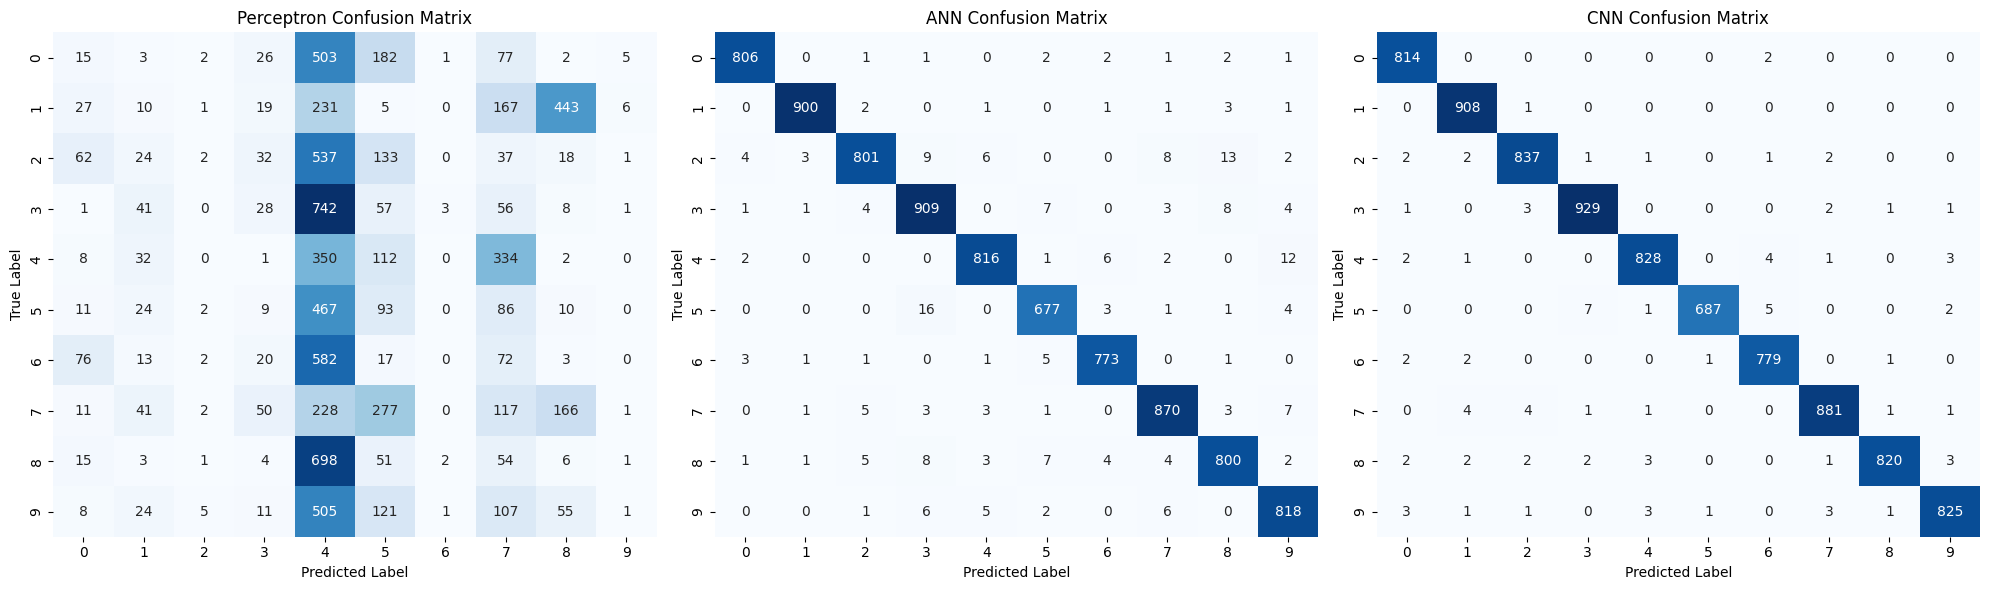

In [142]:
plot_confusion_heatmaps(
    models=[perceptron, ann, cnn],
    model_names=["Perceptron", "ANN", "CNN"],
    X_flat=X_test_img,   # Flat data for Perceptron and ANN
    X_cnn=X_test_cnn,    # Reshaped data for CNN
    y_true=y_test        # True integer labels (not one-hot)
)

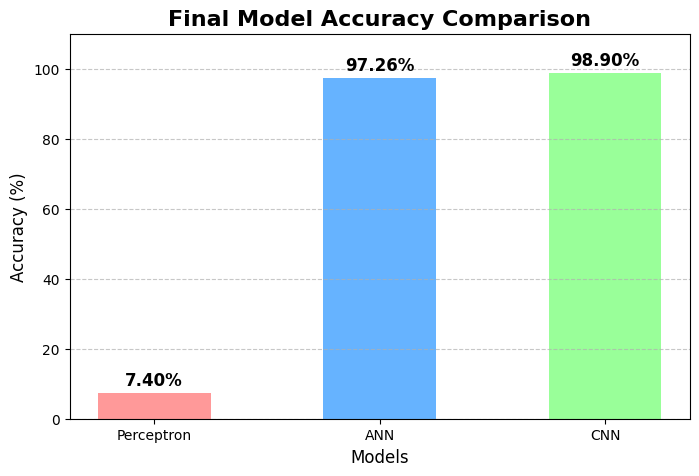

In [145]:
acc_perceptron = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1] * 100
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1] * 100
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1] * 100

# 2. Define the data for the plot
models = ['Perceptron', 'ANN', 'CNN']
accuracies = [acc_perceptron, acc_ann, acc_cnn]
colors = ['#ff9999', '#66b3ff', '#99ff99'] # Light red, light blue, light green

# 3. Create the Bar Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)

# 4. Add the exact percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# 5. Formatting
plt.title('Final Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 110) # Set y-axis limit to 110 so the text labels fit nicely
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# **Saving and Exporting the Trained Model**

Now that our CNN has achieved a high accuracy (98.90%), we need to save its learned parameters (weights and biases) so we can use it later in a real-world application or UI.

**Steps performed below:**
1.  **`cnn.save('cnn_model.keras')`:** We save the entire model architecture, weights, and training configuration into a single file using the `.keras` format (the modern standard for Keras 3).
2.  **`files.download('cnn_model.keras')`:** Because we are working in Google Colab (which runs on a temporary cloud server), this command triggers a download of the saved model file directly to your local machine's hard drive.

*Note: If you were running this locally on your own PC, you would skip the download step and simply use `model.save()` or `model.save_weights()`.*

In [144]:
from google.colab import files

cnn.save('cnn_model.keras')
files.download('cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Analysis of Model Performance (Confusion Matrices)**

The confusion matrices above clearly illustrate the progression of our models from a simple linear classifier to a deep spatial feature extractor:

*   **Perceptron (Left):** The model fails to learn distinct patterns. Notice the massive vertical band in **Column 5**—the model is heavily biased and incorrectly predicts the digit '5' for almost every image. Because it lacks hidden layers, it cannot capture non-linear relationships in the pixel data.
*   **ANN (Center):** A massive improvement. The diagonal is strong, meaning most predictions are correct. However, the model still struggles with visually similar digits. For instance, look at the row for **True Label 5**: it misclassifies several 5s as 3s, 6s, and 8s. Because the ANN flattens the image immediately, it loses the 2D spatial context required to distinguish these subtle curves.
*   **CNN (Right):** The CNN is exceptionally accurate. The off-diagonal cells are almost entirely white, indicating very few misclassifications. By preserving the 2D structure and using Convolutional filters, the CNN successfully learns the spatial hierarchies (edges, loops, curves) necessary to differentiate between tricky digits like 4s and 9s. The `Dropout` layer also ensured it generalized well rather than memorizing the training data.